# PIXEL Model Tutorial: BAREC Readability Classification

This notebook demonstrates how to use the PIXEL (Pixel-based Encoder of Language) model for Arabic readability classification using the BAREC dataset. We'll walk through the entire pipeline from data loading to evaluation, with visualizations of the rendered text patches.

## Table of Contents
1. [Setup and Configuration](#setup)
2. [Data Loading and Preprocessing](#data)
3. [Text Rendering Visualization](#rendering)
4. [Model Training](#training)
5. [Evaluation and Metrics](#evaluation)
6. [Predictions Analysis](#predictions)

## 1. Setup and Configuration {#setup}

First, let's import all necessary libraries and set up our configuration.

In [1]:
import os
import sys
import logging
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from typing import Dict, List, Optional, Union
from dataclasses import dataclass
from sklearn.metrics import accuracy_score, cohen_kappa_score, mean_absolute_error, confusion_matrix
from sklearn.metrics import classification_report
import pandas as pd
from tqdm.auto import tqdm

# PIXEL specific imports
from pixel import (
    PIXELForSequenceClassification,
    PangoCairoTextRenderer,
    PyGameTextRenderer,
    BARECDataset,
    Modality,
    PoolingMode,
    get_transforms,
    resize_model_embeddings,
    MAX_SEQ_LENGTH
)
from transformers import set_seed
from torch.utils.data import DataLoader

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All imports successful!")

/opt/anaconda3/envs/pixel-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports successful!


### Configuration Parameters

Modify these parameters to experiment with different settings:

In [2]:
@dataclass
class Config:
    """Configuration class for the PIXEL BAREC experiment."""
    
    # Model Configuration
    model_name_or_path: str = "Team-PIXEL/pixel-base"  # Base PIXEL model
    renderer_name_or_path: str = "Team-PIXEL/pixel-base"  # Text renderer
    
    # Data Configuration
    dataset_name: str = "CAMeL-Lab/BAREC-Shared-Task-2025-sent"  # Sentence-level dataset
    max_seq_length: int = MAX_SEQ_LENGTH  # Maximum sequence length in patches
    num_labels: int = 19  # Number of readability levels (1-19)
    
    # Training Configuration
    batch_size: int = 8
    learning_rate: float = 5e-5
    num_epochs: int = 3
    warmup_steps: int = 100
    
    # Model Architecture
    pooling_mode: PoolingMode = PoolingMode.MEAN
    dropout_prob: float = 0.1
    
    # Rendering Configuration
    rendering_backend: str = "pangocairo"  # "pangocairo" or "pygame"
    render_rgb: bool = False
    
    # Experiment Configuration
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Visualization
    num_examples_to_show: int = 5
    figsize: tuple = (15, 10)

# Initialize configuration
config = Config()

# Set seed for reproducibility
set_seed(config.seed)

print(f"🔧 Configuration:")
print(f"   Model: {config.model_name_or_path}")
print(f"   Dataset: {config.dataset_name}")
print(f"   Device: {config.device}")
print(f"   Max sequence length: {config.max_seq_length} patches")
print(f"   Rendering backend: {config.rendering_backend}")

🔧 Configuration:
   Model: Team-PIXEL/pixel-base
   Dataset: CAMeL-Lab/BAREC-Shared-Task-2025-sent
   Device: cuda
   Max sequence length: 529 patches
   Rendering backend: pangocairo


## 2. Data Loading and Preprocessing {#data}

Let's load the BAREC dataset and set up the text renderer.

In [3]:
def setup_renderer(config: Config) -> Union[PangoCairoTextRenderer, PyGameTextRenderer]:
    """Set up the text renderer based on configuration."""
    
    renderer_cls = (
        PangoCairoTextRenderer if config.rendering_backend == "pangocairo" 
        else PyGameTextRenderer
    )
    
    renderer = renderer_cls.from_pretrained(
        config.renderer_name_or_path,
        rgb=config.render_rgb
    )
    
    # Set maximum sequence length
    renderer.max_seq_length = config.max_seq_length
    
    logger.info(f"Renderer setup complete:")
    logger.info(f"  Pixels per patch: {renderer.pixels_per_patch}")
    logger.info(f"  Max sequence length: {renderer.max_seq_length}")
    logger.info(f"  Font size: {renderer.font_size}")
    
    return renderer

# Set up renderer
renderer = setup_renderer(config)
print("✅ Text renderer initialized!")

INFO:pixel.data.rendering.rendering_utils:loading text renderer configuration file https://huggingface.co/Team-PIXEL/pixel-base/resolve/main/text_renderer_config.json from cache at /shared_models/.cache/huggingface/transformers/892d6a02d7c441000de399de59ed70d943a81f7b0f536523b4af1111677a8508.e332b34c9c05756dd4aa51d8fa33461dbd79604752296d185f03f8004db30700
INFO:pixel.data.rendering.rendering_utils:loading font file https://huggingface.co/Team-PIXEL/pixel-base/resolve/main/GoNotoCurrent.ttf from cache at /shared_models/.cache/huggingface/transformers/49e6dc219d1a1a1c9236acaf05a48b542002016a6dc877ee72baab085a84257b.3f28e7f4b38e1efe1b6da4a3732404c19d4c6a614ff32dce90a251e293d4ce58
INFO:pixel.data.rendering.pangocairo_renderer:Loading font from /shared_models/.cache/huggingface/transformers/49e6dc219d1a1a1c9236acaf05a48b542002016a6dc877ee72baab085a84257b.3f28e7f4b38e1efe1b6da4a3732404c19d4c6a614ff32dce90a251e293d4ce58
INFO:pixel.data.rendering.rendering_utils:loading font file https://huggin

✅ Text renderer initialized!


In [4]:
def load_datasets(config: Config, renderer) -> Dict[str, BARECDataset]:
    """Load train, validation, and test datasets."""
    
    # Set up transforms for image preprocessing
    transforms = get_transforms(
        do_resize=True,
        size=(renderer.pixels_per_patch, renderer.pixels_per_patch * renderer.max_seq_length),
    )
    
    datasets = {}
    
    for split in ["train", "validation", "test"]:
        try:
            dataset = BARECDataset(
                dataset_name=config.dataset_name,
                processor=renderer,
                modality=Modality.IMAGE,
                max_seq_length=config.max_seq_length,
                split=split,
                transforms=transforms
            )
            datasets[split] = dataset
            logger.info(f"{split.capitalize()} dataset: {len(dataset)} examples")
        except Exception as e:
            logger.warning(f"Could not load {split} split: {e}")
    
    return datasets

# Load datasets
print("📊 Loading datasets...")
datasets = load_datasets(config, renderer)
print("✅ Datasets loaded successfully!")

INFO:pixel.data.datasets.barec_dataset:Creating features from HuggingFace dataset (no cache)


📊 Loading datasets...


/home/bens/pixel/src/pixel/data/datasets/barec_dataset.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
INFO:pixel.data.datasets.barec_dataset:*** Example ***
INFO:pixel.data.datasets.barec_dataset:sentence: مجلة كل الأولاد وكل البنات
INFO:pixel.data.datasets.barec_dataset:attention_mask: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        

✅ Datasets loaded successfully!


### Dataset Overview

Let's examine the structure and distribution of our data:

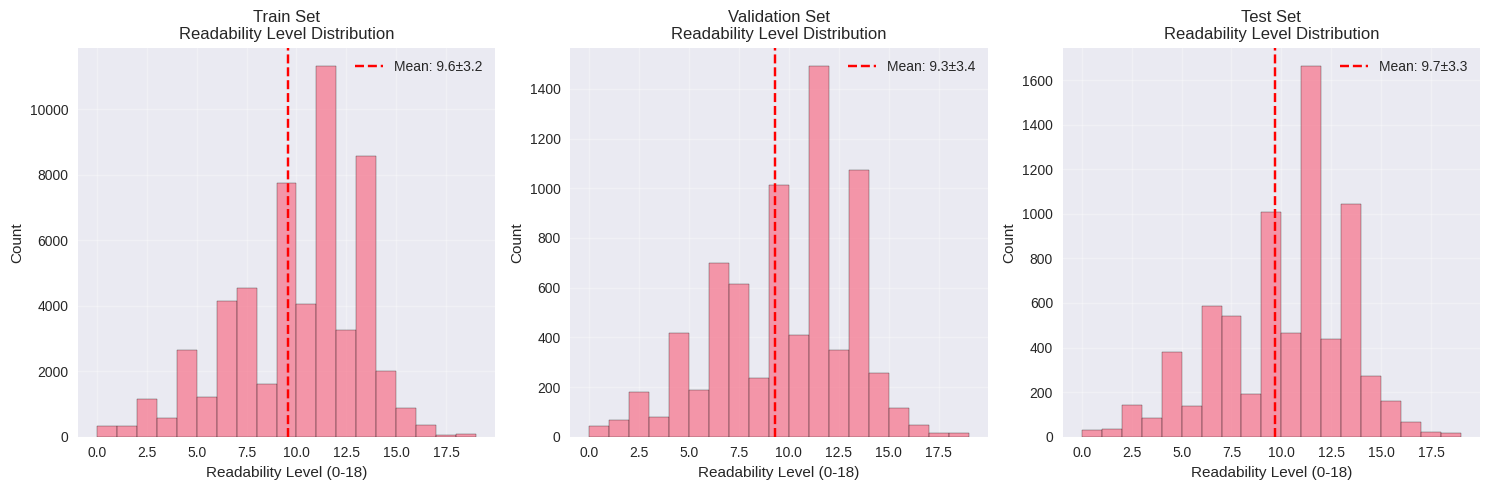


📈 Dataset Summary:

TRAIN:
  Total examples: 54,845
  Mean readability level: 9.57
  Std readability level: 3.24
  Min/Max levels: 0/18

VALIDATION:
  Total examples: 7,310
  Mean readability level: 9.30
  Std readability level: 3.37
  Min/Max levels: 0/18

TEST:
  Total examples: 7,286
  Mean readability level: 9.66
  Std readability level: 3.26
  Min/Max levels: 0/18


In [5]:
def analyze_dataset(datasets: Dict[str, BARECDataset]) -> None:
    """Analyze the dataset distribution and statistics."""
    
    fig, axes = plt.subplots(1, len(datasets), figsize=(15, 5))
    if len(datasets) == 1:
        axes = [axes]
    
    for idx, (split_name, dataset) in enumerate(datasets.items()):
        # Get labels
        labels = [dataset[i]['label'] for i in range(len(dataset))]
        
        # Plot distribution
        axes[idx].hist(labels, bins=range(20), alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{split_name.capitalize()} Set\nReadability Level Distribution')
        axes[idx].set_xlabel('Readability Level (0-18)')
        axes[idx].set_ylabel('Count')
        axes[idx].grid(True, alpha=0.3)
        
        # Add statistics
        mean_level = np.mean(labels)
        std_level = np.std(labels)
        axes[idx].axvline(mean_level, color='red', linestyle='--', 
                         label=f'Mean: {mean_level:.1f}±{std_level:.1f}')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n📈 Dataset Summary:")
    for split_name, dataset in datasets.items():
        labels = [dataset[i]['label'] for i in range(len(dataset))]
        print(f"\n{split_name.upper()}:")
        print(f"  Total examples: {len(dataset):,}")
        print(f"  Mean readability level: {np.mean(labels):.2f}")
        print(f"  Std readability level: {np.std(labels):.2f}")
        print(f"  Min/Max levels: {min(labels)}/{max(labels)}")

analyze_dataset(datasets)

## 3. Text Rendering Visualization {#rendering}

Let's visualize how text is rendered into patches for the PIXEL model:

🎨 Visualizing text rendering process...

📝 Example 1:
   Text: مجلة كل الأولاد وكل البنات
   Readability Level: 7/19
   Active patches: 10/529
   Display width: 208px (based on longest text with 13 patches)

📝 Example 2:
   Text: ماجد
   Readability Level: 1/19
   Active patches: 3/529
   Display width: 208px (based on longest text with 13 patches)

📝 Example 3:
   Text: الأربعاء 21 يناير 1987
   Readability Level: 8/19
   Active patches: 9/529
   Display width: 208px (based on longest text with 13 patches)

📝 Example 4:
   Text: الموافق 21 جمادى الأول 1407هــ
   Readability Level: 7/19
   Active patches: 13/529
   Display width: 208px (based on longest text with 13 patches)

📝 Example 5:
   Text: السنة الثامنة
   Readability Level: 5/19
   Active patches: 6/529
   Display width: 208px (based on longest text with 13 patches)


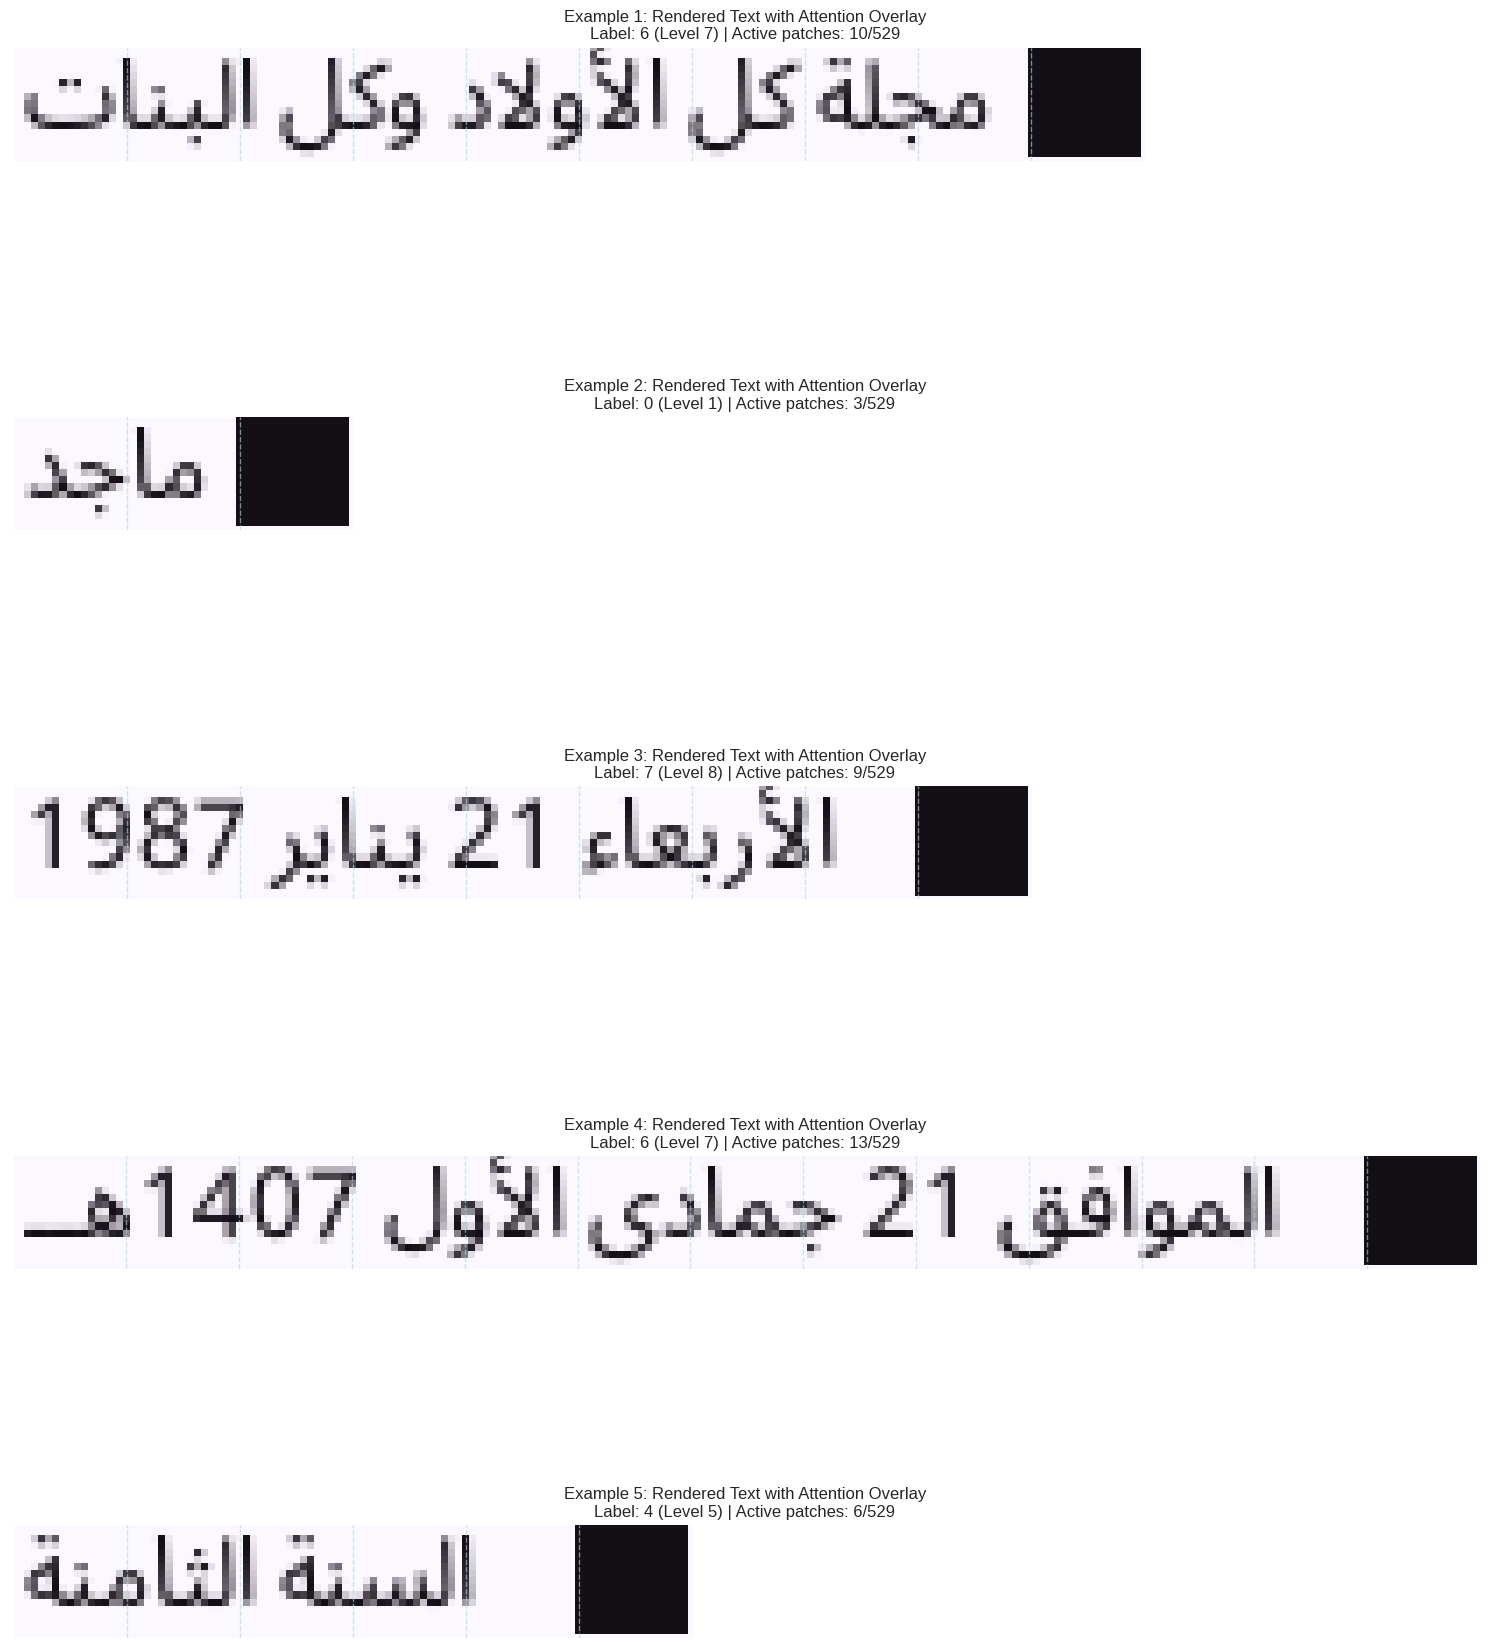

In [6]:
def visualize_text_rendering(dataset: BARECDataset, renderer, num_examples: int = 3) -> None:
    """Visualize how text is rendered into image patches with attention mask overlay."""
    
    # First pass: find the longest text (most active patches) among the examples
    max_active_patches = 0
    for i in range(num_examples):
        example = dataset[i]
        attention_mask = example['attention_mask']
        active_patches = attention_mask.sum().item()
        max_active_patches = max(max_active_patches, active_patches)
    
    # Calculate display width based on longest text
    patch_size = renderer.pixels_per_patch
    display_width = max_active_patches * patch_size
    
    # Single column layout with overlaid attention masks
    fig, axes = plt.subplots(num_examples, 1, figsize=(15, num_examples * 4))
    if num_examples == 1:
        axes = [axes]
    
    for i in range(num_examples):
        # Get example
        example = dataset[i]
        sentence = dataset.examples[i].sentence
        label = example['label']
        pixel_values = example['pixel_values']
        attention_mask = example['attention_mask']
        
        # Convert tensor to numpy for visualization
        if isinstance(pixel_values, torch.Tensor):
            # Assuming pixel_values is in format [C, H, W]
            if pixel_values.dim() == 3:
                img_array = pixel_values.permute(1, 2, 0).numpy()
            else:
                img_array = pixel_values.numpy()
        else:
            img_array = pixel_values
        
        # Ensure proper format for display
        if img_array.ndim == 3 and img_array.shape[2] == 1:
            img_array = img_array.squeeze(2)

        # Truncate to display_width based on longest text
        if img_array.shape[1] > display_width:
            img_array = img_array[:, :display_width, :]
        
        # Display rendered image
        axes[i].imshow(img_array, cmap='gray' if img_array.ndim == 2 else None)
        
        # Create attention mask overlay
        active_patches = attention_mask.sum().item()
        attention_patches = attention_mask[:active_patches]  # Only active patches
        
        # Create overlay for attention mask with pastel color
        if active_patches > 0:
            # Create a colored overlay for each active patch
            overlay_height = img_array.shape[0]
            for patch_idx in range(active_patches):
                if attention_patches[patch_idx] > 0:  # If this patch is active
                    x_start = patch_idx * patch_size
                    x_end = min(x_start + patch_size, img_array.shape[1])
                    
                    # Create a pastel colored rectangle overlay
                    overlay = np.zeros((overlay_height, x_end - x_start, 4))  # RGBA
                    overlay[:, :, 0] = 0.9  # Light red/pink
                    overlay[:, :, 1] = 0.7  # Light green
                    overlay[:, :, 2] = 1.0  # Light blue
                    overlay[:, :, 3] = 0.3  # Low opacity (alpha)
                    
                    # Add the overlay to the plot
                    axes[i].imshow(overlay, extent=[x_start, x_end, overlay_height, 0], alpha=0.3)
        
        axes[i].set_title(f'Example {i+1}: Rendered Text with Attention Overlay\nLabel: {label} (Level {label+1}) | Active patches: {active_patches}/{len(attention_mask)}')
        axes[i].axis('off')
        
        # Add patch boundaries as vertical lines for clarity
        for patch_idx in range(1, active_patches):
            x_pos = patch_idx * patch_size
            if x_pos < img_array.shape[1]:
                axes[i].axvline(x=x_pos, color='lightblue', linestyle='--', alpha=0.6, linewidth=1)
        
        # Print sentence (first 100 chars for readability)
        sentence_preview = sentence[:100] + "..." if len(sentence) > 100 else sentence
        print(f"\n📝 Example {i+1}:")
        print(f"   Text: {sentence_preview}")
        print(f"   Readability Level: {label+1}/19")
        print(f"   Active patches: {active_patches}/{len(attention_mask)}")
        print(f"   Display width: {display_width}px (based on longest text with {max_active_patches} patches)")
    
    plt.tight_layout()
    plt.show()

# Visualize examples from training set
if 'train' in datasets:
    print("🎨 Visualizing text rendering process...")
    visualize_text_rendering(datasets['train'], renderer, config.num_examples_to_show)
else:
    print("⚠️ No training data available for visualization")

### Understanding Patch-based Encoding

Let's dive deeper into how the PIXEL model processes text:

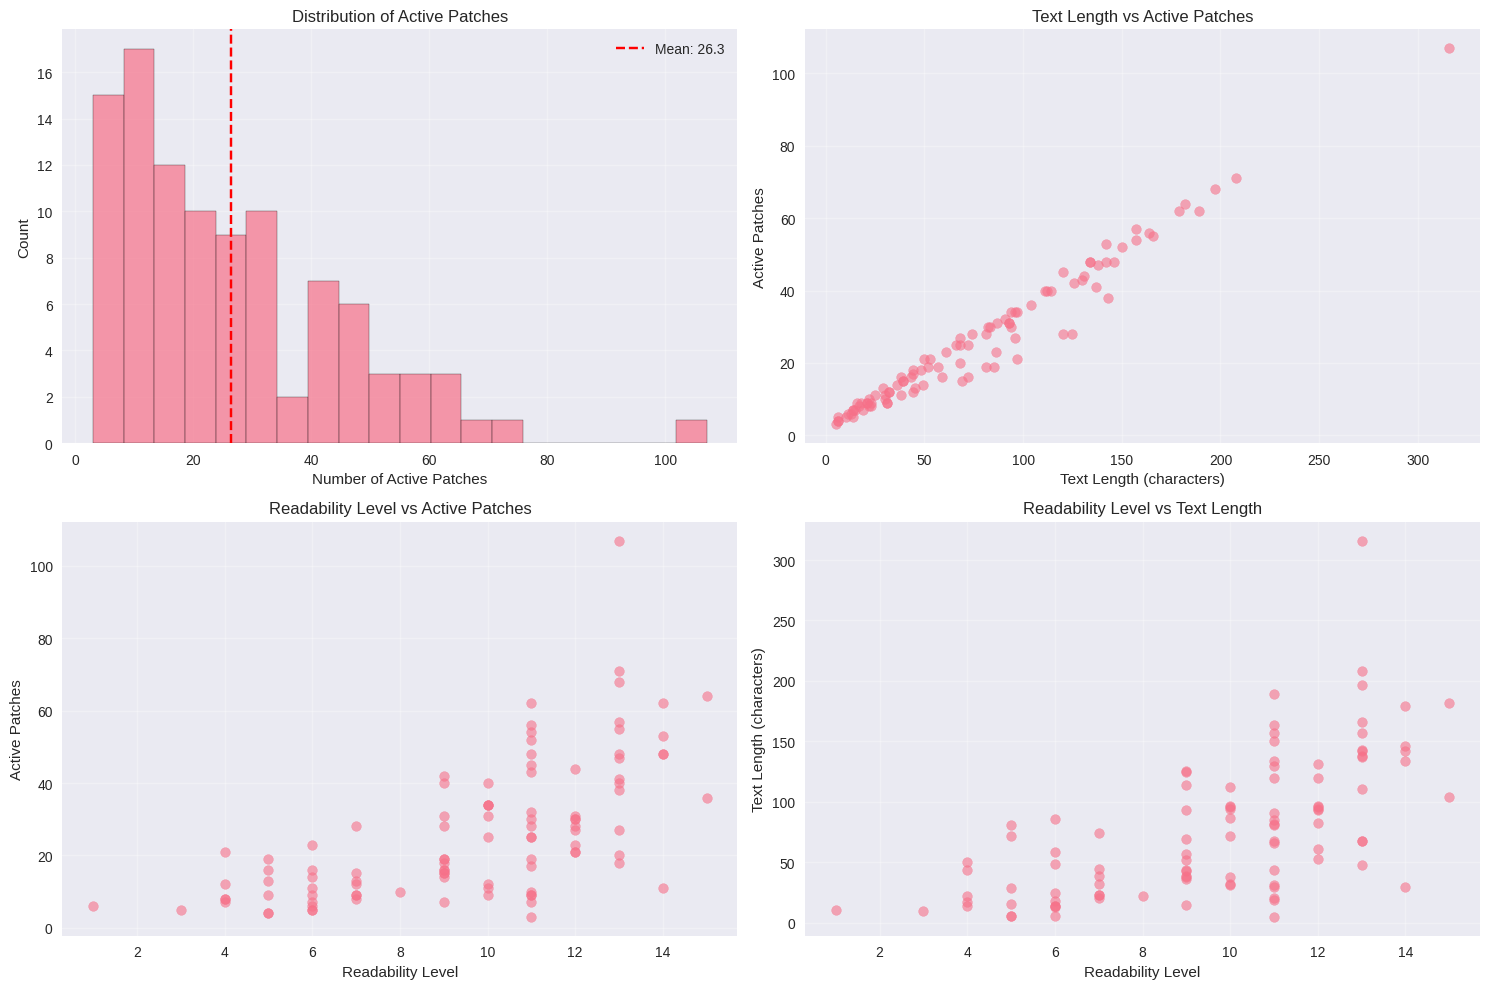


🔍 Correlation Analysis (n=100):
   Text Length ↔ Active Patches: 0.981
   Readability ↔ Active Patches: 0.638
   Readability ↔ Text Length: 0.637


In [7]:
def analyze_patch_usage(dataset: BARECDataset, sample_size: int = 100) -> None:
    """Analyze how patches are used across different examples."""
    
    patch_counts = []
    text_lengths = []
    readability_levels = []
    
    # Sample examples
    indices = np.random.choice(len(dataset), min(sample_size, len(dataset)), replace=False)
    
    for idx in indices:
        example = dataset[idx]
        sentence = dataset.examples[idx].sentence
        
        active_patches = example['attention_mask'].sum().item()
        text_length = len(sentence)
        readability_level = example['label']
        
        patch_counts.append(active_patches)
        text_lengths.append(text_length)
        readability_levels.append(readability_level)
    
    # Create analysis plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Patch count distribution
    axes[0, 0].hist(patch_counts, bins=20, alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Distribution of Active Patches')
    axes[0, 0].set_xlabel('Number of Active Patches')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].axvline(np.mean(patch_counts), color='red', linestyle='--', 
                      label=f'Mean: {np.mean(patch_counts):.1f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Text length vs patches
    axes[0, 1].scatter(text_lengths, patch_counts, alpha=0.6)
    axes[0, 1].set_title('Text Length vs Active Patches')
    axes[0, 1].set_xlabel('Text Length (characters)')
    axes[0, 1].set_ylabel('Active Patches')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Correlation with readability
    axes[1, 0].scatter(readability_levels, patch_counts, alpha=0.6)
    axes[1, 0].set_title('Readability Level vs Active Patches')
    axes[1, 0].set_xlabel('Readability Level')
    axes[1, 0].set_ylabel('Active Patches')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Readability vs text length
    axes[1, 1].scatter(readability_levels, text_lengths, alpha=0.6)
    axes[1, 1].set_title('Readability Level vs Text Length')
    axes[1, 1].set_xlabel('Readability Level')
    axes[1, 1].set_ylabel('Text Length (characters)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print correlations
    patch_text_corr = np.corrcoef(text_lengths, patch_counts)[0, 1]
    patch_readability_corr = np.corrcoef(readability_levels, patch_counts)[0, 1]
    text_readability_corr = np.corrcoef(readability_levels, text_lengths)[0, 1]
    
    print(f"\n🔍 Correlation Analysis (n={len(indices)}):")
    print(f"   Text Length ↔ Active Patches: {patch_text_corr:.3f}")
    print(f"   Readability ↔ Active Patches: {patch_readability_corr:.3f}")
    print(f"   Readability ↔ Text Length: {text_readability_corr:.3f}")

if 'train' in datasets:
    analyze_patch_usage(datasets['train'])

## 4. Model Training {#training}

Now let's set up and train our PIXEL model:

In [8]:
def setup_model(config: Config) -> PIXELForSequenceClassification:
    """Initialize the PIXEL model for sequence classification."""
    
    model = PIXELForSequenceClassification.from_pretrained(
        config.model_name_or_path,
        num_labels=config.num_labels,
        pooling_mode=config.pooling_mode,
        hidden_dropout_prob=config.dropout_prob,
        attention_probs_dropout_prob=config.dropout_prob,
    )
    
    # Resize model embeddings to match our sequence length
    resize_model_embeddings(model, config.max_seq_length)
    
    # Move to device
    model = model.to(config.device)
    
    logger.info(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")
    logger.info(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    return model

# Initialize model
print("🤖 Setting up PIXEL model...")
model = setup_model(config)
print("✅ Model initialized successfully!")

🤖 Setting up PIXEL model...


You are using a model of type pixel to instantiate a model of type vit. This is not supported for all configurations of models and can yield errors.
/opt/anaconda3/envs/pixel-env/lib/python3.9/site-packages/transformers/modeling_utils.py:1439: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have fu

✅ Model initialized successfully!


In [9]:
def create_dataloaders(datasets: Dict[str, BARECDataset], config: Config) -> Dict[str, DataLoader]:
    """Create DataLoaders for training and evaluation."""
    
    def collate_fn(batch):
        """Custom collate function for PIXEL data."""
        pixel_values = torch.stack([item['pixel_values'] for item in batch])
        attention_mask = torch.stack([item['attention_mask'] for item in batch])
        labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
        
        return {
            'pixel_values': pixel_values,
            'attention_mask': attention_mask,
            'labels': labels
        }
    
    dataloaders = {}
    
    for split_name, dataset in datasets.items():
        shuffle = (split_name == 'train')
        batch_size = config.batch_size if split_name == 'train' else config.batch_size * 2
        
        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            collate_fn=collate_fn,
            num_workers=2,
            pin_memory=True if config.device == 'cuda' else False
        )
        
        dataloaders[split_name] = dataloader
        logger.info(f"{split_name} dataloader: {len(dataloader)} batches")
    
    return dataloaders

# Create dataloaders
dataloaders = create_dataloaders(datasets, config)
print("✅ DataLoaders created!")

INFO:__main__:train dataloader: 6856 batches
INFO:__main__:validation dataloader: 457 batches
INFO:__main__:test dataloader: 456 batches
INFO:__main__:validation dataloader: 457 batches
INFO:__main__:test dataloader: 456 batches


✅ DataLoaders created!


### Quick Training Loop

Let's implement a simple training loop to demonstrate the model in action:

In [10]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    num_batches = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for batch in progress_bar:
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Forward pass
        outputs = model(**batch)
        loss = outputs.loss
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        num_batches += 1
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{total_loss/num_batches:.4f}'
        })
    
    return total_loss / num_batches

def evaluate_model(model, dataloader, device):
    """Evaluate the model."""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            # Move batch to device
            batch = {k: v.to(device) for k, v in batch.items()}
            
            # Forward pass
            outputs = model(**batch)
            
            total_loss += outputs.loss.item()
            
            # Get predictions
            predictions = torch.argmax(outputs.logits, dim=-1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    
    return avg_loss, np.array(all_predictions), np.array(all_labels)

# Setup optimizer and scheduler
if 'train' in dataloaders:
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
    
    total_steps = len(dataloaders['train']) * config.num_epochs
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, 
        start_factor=0.1, 
        total_iters=config.warmup_steps
    )
    
    print(f"🏃‍♂️ Training setup complete:")
    print(f"   Total training steps: {total_steps}")
    print(f"   Warmup steps: {config.warmup_steps}")
    print(f"   Learning rate: {config.learning_rate}")
else:
    print("⚠️ No training data available")

🏃‍♂️ Training setup complete:
   Total training steps: 20568
   Warmup steps: 100
   Learning rate: 5e-05


In [11]:
# Quick training demonstration (reduced epochs for notebook)
if 'train' in dataloaders:
    print("🚀 Starting training...")
    
    training_history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_qwk': []
    }
    
    # Reduce epochs for demo (you can increase for actual training)
    demo_epochs = min(2, config.num_epochs)
    
    for epoch in range(demo_epochs):
        print(f"\n📚 Epoch {epoch + 1}/{demo_epochs}")
        
        # Training
        train_loss = train_epoch(model, dataloaders['train'], optimizer, scheduler, config.device)
        training_history['train_loss'].append(train_loss)
        
        # Validation
        if 'validation' in dataloaders:
            val_loss, val_preds, val_labels = evaluate_model(model, dataloaders['validation'], config.device)
            val_accuracy = accuracy_score(val_labels, val_preds)
            val_qwk = cohen_kappa_score(val_labels, val_preds, weights='quadratic')
            
            training_history['val_loss'].append(val_loss)
            training_history['val_accuracy'].append(val_accuracy)
            training_history['val_qwk'].append(val_qwk)
            
            print(f"\n📊 Epoch {epoch + 1} Results:")
            print(f"   Train Loss: {train_loss:.4f}")
            print(f"   Val Loss: {val_loss:.4f}")
            print(f"   Val Accuracy: {val_accuracy:.4f}")
            print(f"   Val QWK: {val_qwk:.4f}")
        else:
            print(f"\n📊 Epoch {epoch + 1} Results:")
            print(f"   Train Loss: {train_loss:.4f}")
    
    print("\n✅ Training complete!")
else:
    print("⚠️ Skipping training - no training data available")
    training_history = None

🚀 Starting training...

📚 Epoch 1/2


Training: 100%|██████████| 6856/6856 [42:27<00:00,  2.69it/s, loss=1.6507, avg_loss=2.0649]

Evaluating: 100%|██████████| 457/457 [02:09<00:00,  3.52it/s]




📊 Epoch 1 Results:
   Train Loss: 2.0649
   Val Loss: 2.0802
   Val Accuracy: 0.2557
   Val QWK: 0.3278

📚 Epoch 2/2


Training: 100%|██████████| 6856/6856 [44:59<00:00,  2.54it/s, loss=1.6968, avg_loss=1.9866]

Evaluating: 100%|██████████| 457/457 [02:10<00:00,  3.51it/s]




📊 Epoch 2 Results:
   Train Loss: 1.9866
   Val Loss: 2.0177
   Val Accuracy: 0.2897
   Val QWK: 0.6153

✅ Training complete!


### Training Progress Visualization

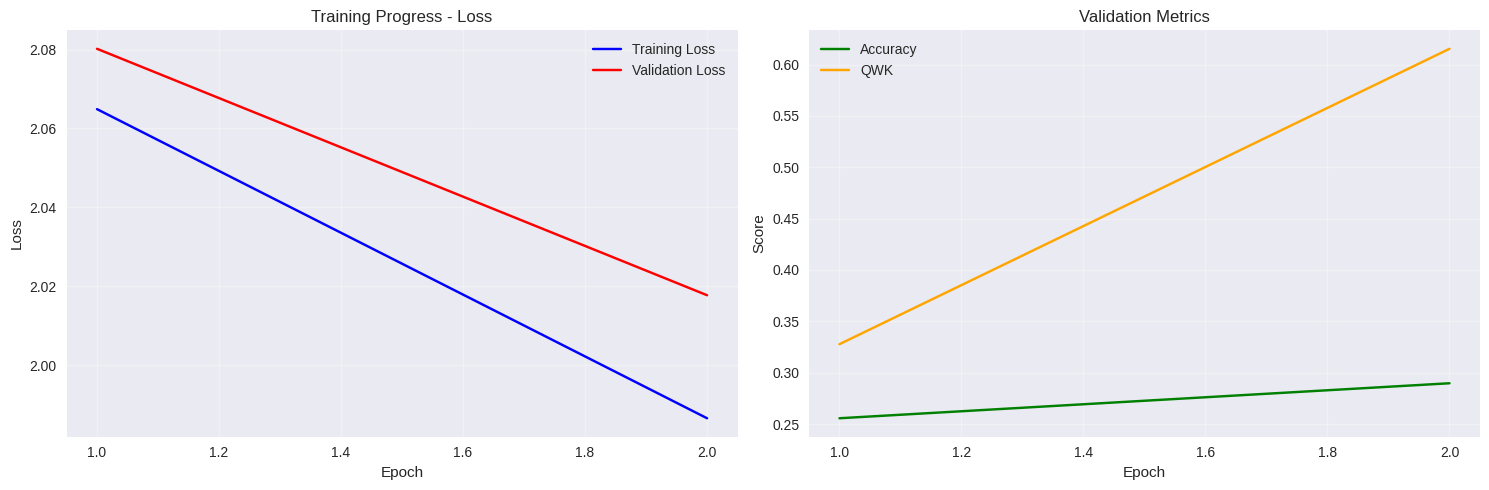

In [12]:
if training_history and len(training_history['train_loss']) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(training_history['train_loss']) + 1)
    
    # Loss curves
    axes[0].plot(epochs, training_history['train_loss'], 'b-', label='Training Loss')
    if training_history['val_loss']:
        axes[0].plot(epochs, training_history['val_loss'], 'r-', label='Validation Loss')
    axes[0].set_title('Training Progress - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Metrics curves
    if training_history['val_accuracy']:
        axes[1].plot(epochs, training_history['val_accuracy'], 'g-', label='Accuracy')
        axes[1].plot(epochs, training_history['val_qwk'], 'orange', label='QWK')
        axes[1].set_title('Validation Metrics')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Score')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No validation data', 
                    horizontalalignment='center', verticalalignment='center',
                    transform=axes[1].transAxes, fontsize=14)
        axes[1].set_title('Validation Metrics')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No training history to display")

## 5. Evaluation and Metrics {#evaluation}

Let's evaluate our model using comprehensive metrics:

In [13]:
def compute_comprehensive_metrics(y_true, y_pred):
    """Compute comprehensive evaluation metrics."""
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'qwk': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(np.mean((y_true - y_pred) ** 2)),
    }
    
    # Adjacent accuracy (within 1 level)
    adjacent_correct = np.sum(np.abs(y_true - y_pred) <= 1)
    metrics['adjacent_accuracy'] = adjacent_correct / len(y_true)
    
    return metrics

def evaluate_comprehensive(model, dataloaders, device, split_name='validation'):
    """Perform comprehensive evaluation."""
    
    if split_name not in dataloaders:
        print(f"⚠️ {split_name} data not available")
        return None, None, None
    
    print(f"🔍 Evaluating on {split_name} set...")
    
    loss, predictions, labels = evaluate_model(model, dataloaders[split_name], device)
    metrics = compute_comprehensive_metrics(labels, predictions)
    
    print(f"\n📊 {split_name.capitalize()} Results:")
    print(f"   Loss: {loss:.4f}")
    print(f"   Accuracy: {metrics['accuracy']:.4f}")
    print(f"   Adjacent Accuracy (±1): {metrics['adjacent_accuracy']:.4f}")
    print(f"   Quadratic Weighted Kappa: {metrics['qwk']:.4f}")
    print(f"   Mean Absolute Error: {metrics['mae']:.4f}")
    print(f"   Root Mean Square Error: {metrics['rmse']:.4f}")
    
    return predictions, labels, metrics

# Evaluate on available splits
evaluation_results = {}

for split in ['validation', 'test']:
    if split in dataloaders:
        preds, labels, metrics = evaluate_comprehensive(model, dataloaders, config.device, split)
        evaluation_results[split] = {
            'predictions': preds,
            'labels': labels,
            'metrics': metrics
        }

🔍 Evaluating on validation set...


Evaluating: 100%|██████████| 457/457 [02:06<00:00,  3.61it/s]




📊 Validation Results:
   Loss: 2.0177
   Accuracy: 0.2897
   Adjacent Accuracy (±1): 0.4186
   Quadratic Weighted Kappa: 0.6153
   Mean Absolute Error: 2.0257
   Root Mean Square Error: 2.8121
🔍 Evaluating on test set...


Evaluating: 100%|██████████| 456/456 [02:09<00:00,  3.51it/s]




📊 Test Results:
   Loss: 2.0272
   Accuracy: 0.2804
   Adjacent Accuracy (±1): 0.4145
   Quadratic Weighted Kappa: 0.6172
   Mean Absolute Error: 1.9948
   Root Mean Square Error: 2.7134


### Detailed Results Visualization

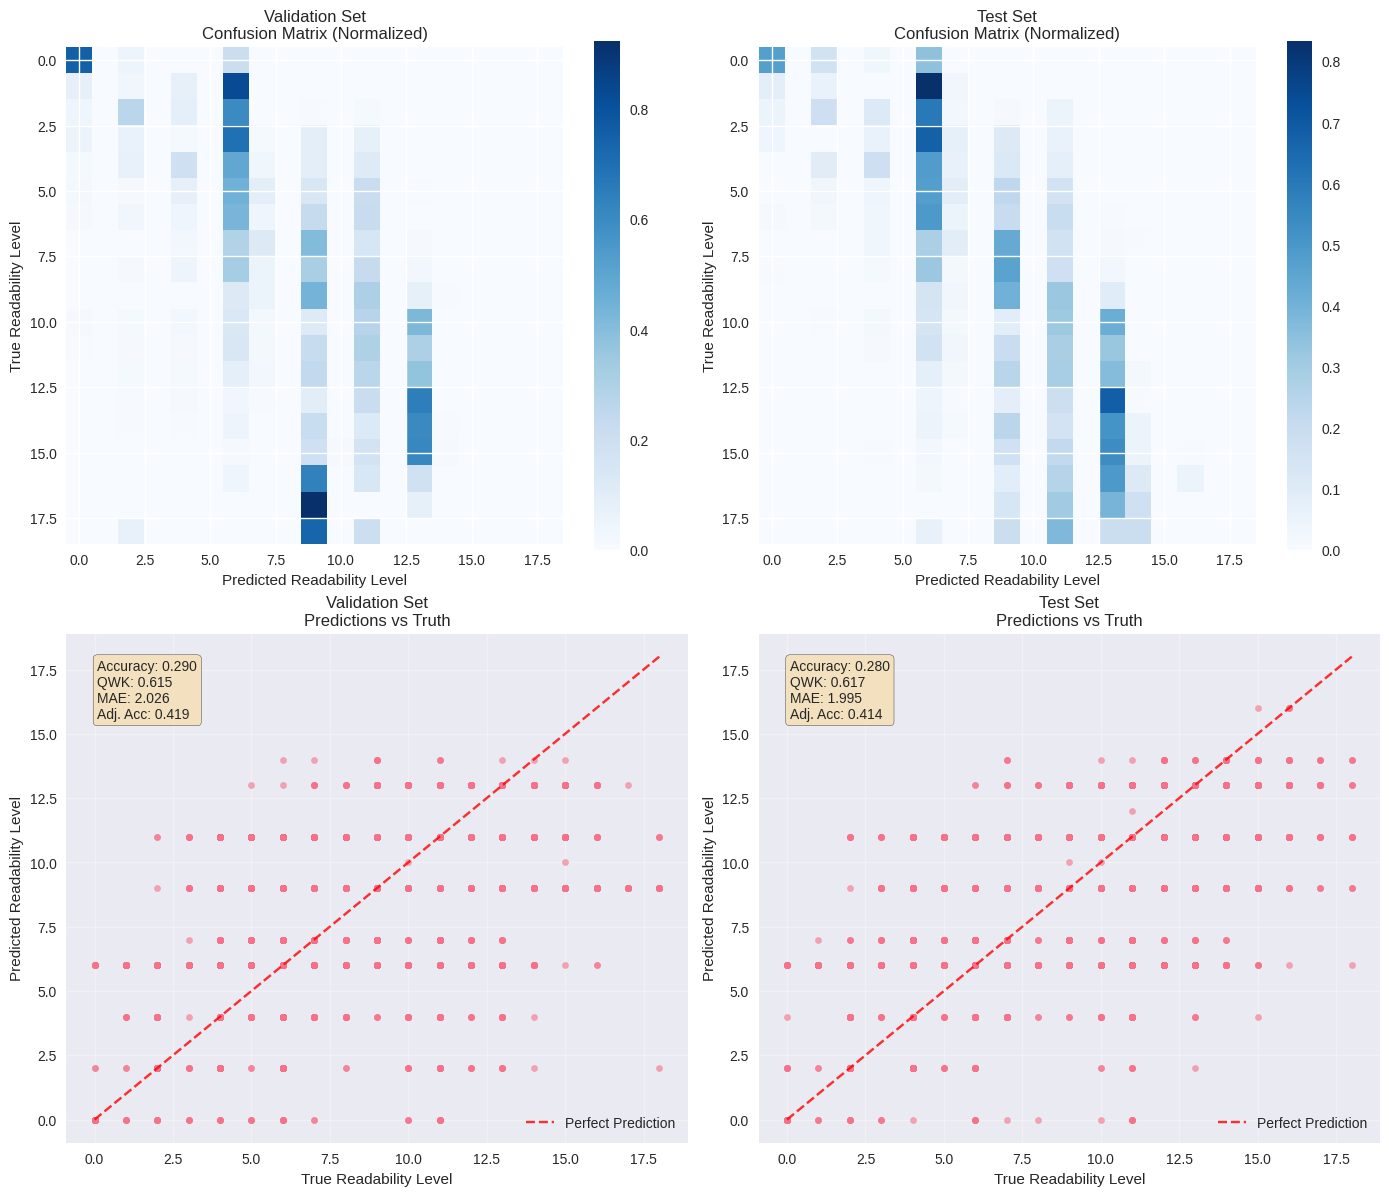

In [14]:
def plot_evaluation_results(evaluation_results):
    """Plot comprehensive evaluation results."""
    
    n_splits = len(evaluation_results)
    if n_splits == 0:
        print("⚠️ No evaluation results to display")
        return
    
    fig, axes = plt.subplots(2, n_splits, figsize=(7*n_splits, 12))
    if n_splits == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (split_name, results) in enumerate(evaluation_results.items()):
        predictions = results['predictions']
        labels = results['labels']
        metrics = results['metrics']
        
        # Confusion Matrix
        cm = confusion_matrix(labels, predictions)
        
        # Normalize confusion matrix
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        im = axes[0, idx].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
        axes[0, idx].set_title(f'{split_name.capitalize()} Set\nConfusion Matrix (Normalized)')
        axes[0, idx].set_xlabel('Predicted Readability Level')
        axes[0, idx].set_ylabel('True Readability Level')
        
        # Add colorbar
        plt.colorbar(im, ax=axes[0, idx])
        
        # Prediction vs Truth Scatter
        axes[1, idx].scatter(labels, predictions, alpha=0.6, s=20)
        axes[1, idx].plot([0, 18], [0, 18], 'r--', alpha=0.8, label='Perfect Prediction')
        axes[1, idx].set_xlabel('True Readability Level')
        axes[1, idx].set_ylabel('Predicted Readability Level')
        axes[1, idx].set_title(f'{split_name.capitalize()} Set\nPredictions vs Truth')
        axes[1, idx].legend()
        axes[1, idx].grid(True, alpha=0.3)
        
        # Add metrics as text
        metrics_text = f"""Accuracy: {metrics['accuracy']:.3f}
QWK: {metrics['qwk']:.3f}
MAE: {metrics['mae']:.3f}
Adj. Acc: {metrics['adjacent_accuracy']:.3f}"""
        
        axes[1, idx].text(0.05, 0.95, metrics_text, transform=axes[1, idx].transAxes,
                         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_evaluation_results(evaluation_results)

### Error Analysis

In [15]:
def analyze_errors(evaluation_results, datasets):
    """Analyze prediction errors in detail."""
    
    for split_name, results in evaluation_results.items():
        predictions = results['predictions']
        labels = results['labels']
        
        print(f"\n🔍 Error Analysis - {split_name.capitalize()} Set:")
        
        # Calculate errors
        errors = predictions - labels
        abs_errors = np.abs(errors)
        
        # Error distribution
        print(f"\n📊 Error Distribution:")
        error_counts = {}
        for error in range(-18, 19):
            count = np.sum(errors == error)
            if count > 0:
                error_counts[error] = count
        
        for error, count in sorted(error_counts.items()):
            percentage = count / len(errors) * 100
            print(f"   Error {error:+2d}: {count:4d} ({percentage:5.1f}%)")
        
        # Worst predictions
        print(f"\n❌ Worst Predictions (|error| >= 3):")
        worst_indices = np.where(abs_errors >= 3)[0]
        
        if len(worst_indices) > 0:
            # Show a few examples
            for i, idx in enumerate(worst_indices[:5]):
                if split_name in datasets:
                    example = datasets[split_name].examples[idx]
                    sentence_preview = example.sentence[:100] + "..." if len(example.sentence) > 100 else example.sentence
                    print(f"\n   Example {i+1}:")
                    print(f"     Text: {sentence_preview}")
                    print(f"     True: Level {labels[idx]+1}, Predicted: Level {predictions[idx]+1}")
                    print(f"     Error: {errors[idx]:+d}")
        else:
            print("   No predictions with |error| >= 3")
        
        # Error by readability level
        print(f"\n📈 Average Absolute Error by True Readability Level:")
        for level in range(19):
            level_mask = labels == level
            if np.sum(level_mask) > 0:
                level_mae = np.mean(abs_errors[level_mask])
                level_count = np.sum(level_mask)
                print(f"   Level {level+1:2d}: {level_mae:.3f} (n={level_count})")

analyze_errors(evaluation_results, datasets)


🔍 Error Analysis - Validation Set:

📊 Error Distribution:
   Error -16:    1 (  0.0%)
   Error -12:    1 (  0.0%)
   Error -11:   12 (  0.2%)
   Error -10:   10 (  0.1%)
   Error -9:   33 (  0.5%)
   Error -8:   33 (  0.5%)
   Error -7:   82 (  1.1%)
   Error -6:   74 (  1.0%)
   Error -5:  287 (  3.9%)
   Error -4:  240 (  3.3%)
   Error -3:  269 (  3.7%)
   Error -2:  823 ( 11.3%)
   Error -1:  509 (  7.0%)
   Error +0: 2118 ( 29.0%)
   Error +1:  433 (  5.9%)
   Error +2: 1238 ( 16.9%)
   Error +3:  460 (  6.3%)
   Error +4:  305 (  4.2%)
   Error +5:  261 (  3.6%)
   Error +6:   61 (  0.8%)
   Error +7:   50 (  0.7%)
   Error +8:    8 (  0.1%)
   Error +9:    2 (  0.0%)

❌ Worst Predictions (|error| >= 3):

   Example 1:
     Text: الاربعاء 13 يوليو 1983م
     True: Level 8, Predicted: Level 12
     Error: +4

   Example 2:
     Text: عيد سعيد
     True: Level 2, Predicted: Level 7
     Error: +5

   Example 3:
     Text: العنقاء
     True: Level 12, Predicted: Level 3
     Error:

## 6. Predictions Analysis {#predictions}

Let's analyze some specific predictions to understand the model's behavior:

In [16]:
def analyze_predictions_qualitatively(model, dataset, device, num_examples=5):
    """Qualitative analysis of individual predictions."""
    
    model.eval()
    
    # Select random examples
    indices = np.random.choice(len(dataset), num_examples, replace=False)
    
    print(f"🔍 Qualitative Analysis - {num_examples} Random Examples:")
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Get example
            example = dataset[idx]
            sentence = dataset.examples[idx].sentence
            true_label = example['label']
            
            # Prepare input
            pixel_values = example['pixel_values'].unsqueeze(0).to(device)
            attention_mask = example['attention_mask'].unsqueeze(0).to(device)
            
            # Get prediction
            outputs = model(pixel_values=pixel_values, attention_mask=attention_mask)
            predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
            predicted_label = torch.argmax(predictions, dim=-1).item()
            confidence = predictions[0, predicted_label].item()
            
            # Display results
            print(f"\n📝 Example {i+1}:")
            print(f"   Text: {sentence[:150]}{'...' if len(sentence) > 150 else ''}")
            print(f"   True Level: {true_label + 1}/19")
            print(f"   Predicted Level: {predicted_label + 1}/19")
            print(f"   Confidence: {confidence:.3f}")
            print(f"   Error: {predicted_label - true_label:+d}")
            
            # Show top 3 predictions
            top3_indices = torch.topk(predictions[0], 3).indices
            top3_probs = torch.topk(predictions[0], 3).values
            
            print(f"   Top 3 predictions:")
            for j, (pred_idx, prob) in enumerate(zip(top3_indices, top3_probs)):
                print(f"     {j+1}. Level {pred_idx.item() + 1}: {prob.item():.3f}")
            
            # Active patches info
            active_patches = attention_mask.sum().item()
            print(f"   Active patches: {active_patches}/{attention_mask.shape[1]}")

# Analyze predictions on validation set if available
if 'validation' in datasets:
    analyze_predictions_qualitatively(model, datasets['validation'], config.device)
elif 'train' in datasets:
    print("Using training set for qualitative analysis:")
    analyze_predictions_qualitatively(model, datasets['train'], config.device)
else:
    print("⚠️ No data available for qualitative analysis")

🔍 Qualitative Analysis - 5 Random Examples:

📝 Example 1:
   Text: العمليات الحسابية التي تستخدم في معالجة البيانات المداخلة هي (أ) (+، -، ÷) فقط (ب) #ERROR! (ج) ٪ (د) × ،÷ ،_ ،+
   True Level: 10/19
   Predicted Level: 14/19
   Confidence: 0.381
   Error: +4
   Top 3 predictions:
     1. Level 14: 0.381
     2. Level 12: 0.243
     3. Level 11: 0.138
   Active patches: 39/529

📝 Example 2:
   Text: ومع عدم معرفته بالتاريخ والجغرافيا، ساعدته خبرته العملية الغزيرة في حل أصعب المشكلات، وفي أن يسوس مئات الأشخاص.
   True Level: 12/19
   Predicted Level: 14/19
   Confidence: 0.516
   Error: +2
   Top 3 predictions:
     1. Level 14: 0.516
     2. Level 12: 0.226
     3. Level 15: 0.087
   Active patches: 41/529

📝 Example 3:
   Text: معنى كلمة يفرحني : (أ) يؤنسني (ب) يحزنني (ج) يضمني (د) يسرني
   True Level: 12/19
   Predicted Level: 12/19
   Confidence: 0.173
   Error: +0
   Top 3 predictions:
     1. Level 12: 0.173
     2. Level 10: 0.160
     3. Level 13: 0.103
   Active patches: 23/529

### Model Confidence Analysis

Analyzing confidence: 100%|██████████| 457/457 [02:05<00:00,  3.63it/s]



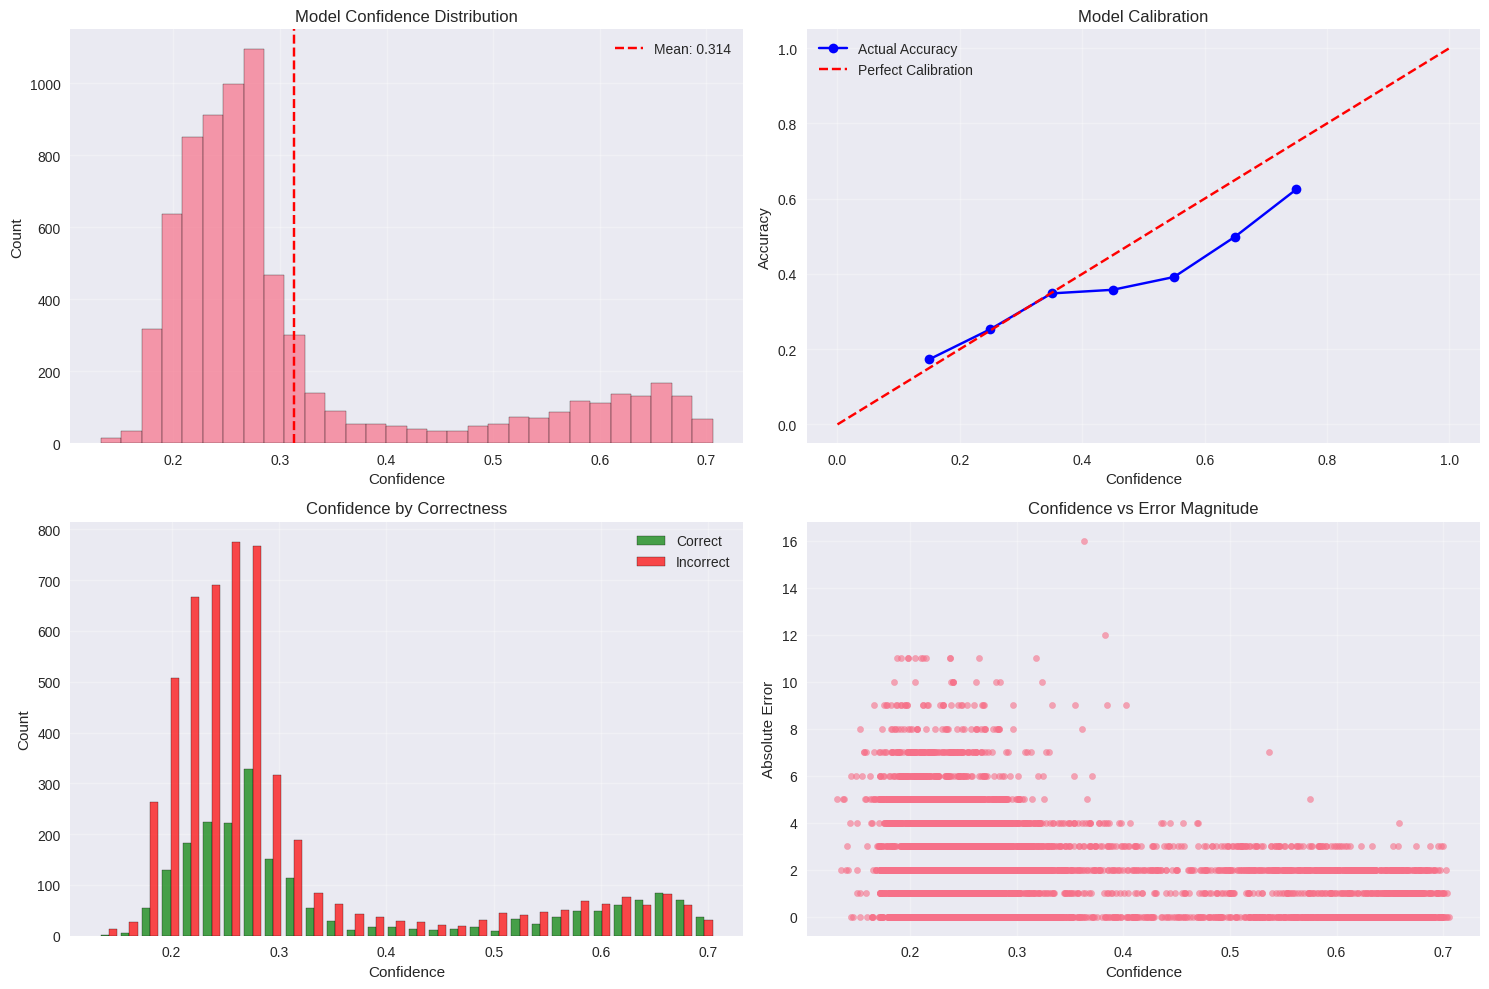


📊 Confidence Analysis:
   Mean confidence: 0.314
   Std confidence: 0.140
   Mean confidence (correct): 0.355
   Mean confidence (incorrect): 0.297


In [17]:
def analyze_model_confidence(model, dataloader, device):
    """Analyze model confidence patterns."""
    
    model.eval()
    
    all_confidences = []
    all_predictions = []
    all_labels = []
    all_correct = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Analyzing confidence"):
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(**{k: v for k, v in batch.items() if k != 'labels'})
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            predictions = torch.argmax(probs, dim=-1)
            confidences = torch.max(probs, dim=-1)[0]
            
            all_confidences.extend(confidences.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
            all_correct.extend((predictions == batch['labels']).cpu().numpy())
    
    all_confidences = np.array(all_confidences)
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_correct = np.array(all_correct)
    
    # Plot confidence analysis
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Confidence distribution
    axes[0, 0].hist(all_confidences, bins=30, alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(np.mean(all_confidences), color='red', linestyle='--', 
                      label=f'Mean: {np.mean(all_confidences):.3f}')
    axes[0, 0].set_title('Model Confidence Distribution')
    axes[0, 0].set_xlabel('Confidence')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Confidence vs Accuracy
    confidence_bins = np.linspace(0, 1, 11)
    bin_accuracies = []
    bin_centers = []
    
    for i in range(len(confidence_bins) - 1):
        mask = (all_confidences >= confidence_bins[i]) & (all_confidences < confidence_bins[i+1])
        if np.sum(mask) > 0:
            bin_accuracy = np.mean(all_correct[mask])
            bin_accuracies.append(bin_accuracy)
            bin_centers.append((confidence_bins[i] + confidence_bins[i+1]) / 2)
    
    axes[0, 1].plot(bin_centers, bin_accuracies, 'bo-', label='Actual Accuracy')
    axes[0, 1].plot([0, 1], [0, 1], 'r--', label='Perfect Calibration')
    axes[0, 1].set_title('Model Calibration')
    axes[0, 1].set_xlabel('Confidence')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Confidence by correctness
    correct_confidences = all_confidences[all_correct]
    incorrect_confidences = all_confidences[~all_correct]
    
    axes[1, 0].hist([correct_confidences, incorrect_confidences], 
                   bins=30, alpha=0.7, label=['Correct', 'Incorrect'], 
                   color=['green', 'red'], edgecolor='black')
    axes[1, 0].set_title('Confidence by Correctness')
    axes[1, 0].set_xlabel('Confidence')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Error magnitude vs confidence
    error_magnitudes = np.abs(all_predictions - all_labels)
    axes[1, 1].scatter(all_confidences, error_magnitudes, alpha=0.6, s=20)
    axes[1, 1].set_title('Confidence vs Error Magnitude')
    axes[1, 1].set_xlabel('Confidence')
    axes[1, 1].set_ylabel('Absolute Error')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n📊 Confidence Analysis:")
    print(f"   Mean confidence: {np.mean(all_confidences):.3f}")
    print(f"   Std confidence: {np.std(all_confidences):.3f}")
    print(f"   Mean confidence (correct): {np.mean(correct_confidences):.3f}")
    print(f"   Mean confidence (incorrect): {np.mean(incorrect_confidences):.3f}")
    
    return all_confidences, all_correct

# Analyze confidence on validation set if available
if 'validation' in dataloaders:
    confidences, correct = analyze_model_confidence(model, dataloaders['validation'], config.device)
else:
    print("⚠️ No validation data available for confidence analysis")